# Q-Learning

Q-Learning is an **off-policy** Temporal Difference control algorithm. "Off-policy" means it
learns the value of the **optimal** greedy policy, regardless of the actions the agent
actually takes while exploring.

### Update Equation

Q(s,a) <- Q(s,a) + α [ R + γ * max_a' Q(s',a') - Q(s,a) ]

Notice the `max_a' Q(s',a')` term - Q-Learning always bootstraps off the **best possible**
next action, not the one it actually took next (that's what makes it off-policy, unlike SARSA).

We use the `FrozenLake-v1` environment, a 4x4 grid where the agent must reach the goal
without falling into a hole, on a slippery (stochastic) surface.


In [1]:
!pip install -q "gymnasium[toy-text]"

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Create Environment

In [3]:
env = gym.make("FrozenLake-v1", is_slippery=True)

state_size = env.observation_space.n
action_size = env.action_space.n

print("States:", state_size)
print("Actions:", action_size)


States: 16
Actions: 4


## Initialize Q-Table

In [4]:
Q = np.zeros((state_size, action_size))
print(Q)


[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


## Hyperparameters (Epsilon-Greedy with Decay)

In [5]:
alpha = 0.8
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01

episodes = 2000
rewards = []


## Training Loop

In [6]:
for episode in range(episodes):

    state, _ = env.reset()
    total_reward = 0

    for step in range(100):

        # epsilon-greedy strategy
        if np.random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state, :])

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Q-learning update - always uses the max Q-value of next state
        Q[state, action] = Q[state, action] + alpha * (
            reward + gamma * np.max(Q[next_state, :]) - Q[state, action]
        )

        state = next_state
        total_reward += reward

        if done:
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    rewards.append(total_reward)

print("Training Completed!")


Training Completed!


## Rewards Graph

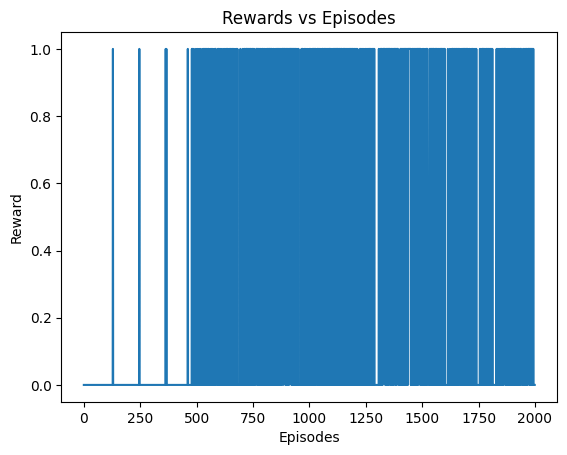

In [7]:
plt.plot(rewards)
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("Rewards vs Episodes")
plt.show()


## Q-Table Heatmap

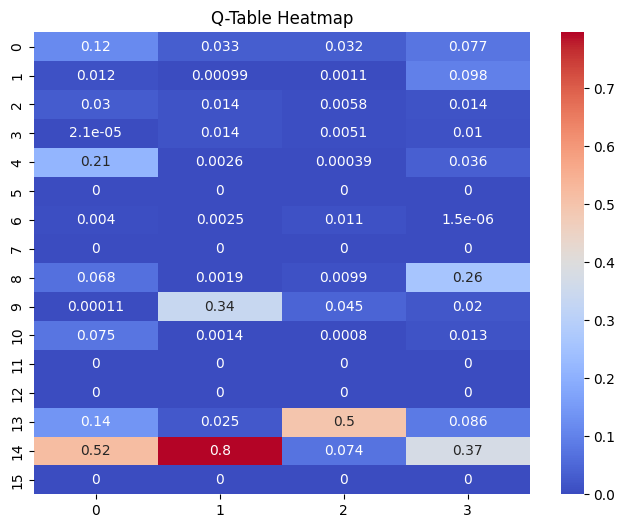

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(Q, annot=True, cmap="coolwarm")
plt.title("Q-Table Heatmap")
plt.show()


## Evaluation (Success Rate)

In [9]:
test_episodes = 100
success = 0

for _ in range(test_episodes):

    state, _ = env.reset()

    for step in range(100):

        action = np.argmax(Q[state, :])
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        state = next_state

        if done:
            if reward == 1:
                success += 1
            break

print("Success Rate:", success / test_episodes)


Success Rate: 0.68


## Final Policy

In [10]:
policy = np.argmax(Q, axis=1)
print("Learned Policy (4x4 grid):")
print(policy.reshape(4, 4))

# 0=LEFT, 1=DOWN, 2=RIGHT, 3=UP


Learned Policy (4x4 grid):
[[0 3 0 1]
 [0 0 2 0]
 [3 1 0 0]
 [0 2 1 0]]


## Conclusion

The trained Q-Learning agent learns a policy purely by bootstrapping off the best possible
future action at every step, even while exploring randomly. Because `FrozenLake` is slippery
(stochastic transitions), the agent won't always reach 100% success even with an optimal
policy - some failures come from the environment itself, not from the policy being wrong.
